# Hackathon BDM: Cell Tracking

Runs the movement-only BDM ABM (`ABM_packageHackathon.py`) with cell ID tracking, saves the output, and visualizes grid snapshots, population dynamics, and individual cell trajectories.

**Edit only the Parameters cell** to change the simulation setup.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import os
from ABM_packageHackathon import *

## Parameters
All inputs are here. Run the cells below after editing.

In [2]:
# ── Simulation ────────────────────────────────────────────────────────────────
rm              = 1.0    # migration rate
scale           = 2      # density-dependent rate scaling factor
T_end           = 15.0   # end time (before non-dimensionalization by rm)
initial_density = 0.3    # initial cell density (fraction of lattice sites)
record_every    = None   # time between grid snapshots; None -> T_final / 50

# ── Saving ────────────────────────────────────────────────────────────────────
save_dir  = '../data'
save_name = 'hackathon_BDM_rm{}_scale{}_dens{}_T{}.npy'.format(
    rm, scale, initial_density, T_end
)

# ── Visualization ─────────────────────────────────────────────────────────────
snap_frames = [0, 10, 25, -1]  # frame indices to show (negative = from end)
n_track     = 8                # number of cells to trace in trajectory plot

## Run

In [3]:
A_out, t_out, plot_list, interp_profiles = BDM_ABM(
    rm, scale, T_end, initial_density, record_every=record_every
)

# Resolve the actual record interval and build per-frame time array
T_final = T_end / rm
rec = T_final / 50 if record_every is None else record_every
frame_times = np.array([i * rec for i in range(len(plot_list))])

print('Simulation complete.')
print('  Frames saved:   {}'.format(len(plot_list)))
print('  Grid shape:     {}'.format(np.array(plot_list).shape))
print('  T_final:        {:.3f}  (non-dim)'.format(T_final))
print('  Frame interval: {:.3f}'.format(rec))

Running ABM:   0%|          | 0/50 [00:00<?, ?it/s]

Running ABM: 100%|██████████| 50/50 [00:17<00:00,  2.89it/s]


Simulation complete.
  Frames saved:   51
  Grid shape:     (51, 120, 120)
  T_final:        15.000  (non-dim)
  Frame interval: 0.300


## Save

In [4]:
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, save_name)

plot_arr = np.array(plot_list)  # shape: (n_frames, 120, 120), dtype int

data = {
    'A_out':           A_out,
    't_out':           t_out,
    'plot_list':       plot_arr,
    'interp_profiles': interp_profiles,
    'params': {
        'rm':              rm,
        'scale':           scale,
        'T_end':           T_end,
        'initial_density': initial_density,
        'record_every':    rec,
    }
}
np.save(save_path, data)
print('Saved -> {}'.format(save_path))
print('  plot_list shape: {}  (int cell-ID grids)'.format(plot_arr.shape))

Saved -> ../data/hackathon_BDM_rm1.0_scale2_dens0.3_T15.0.npy
  plot_list shape: (51, 120, 120)  (int cell-ID grids)


## Visualize
### 1 — Grid snapshots (colored by cell ID)

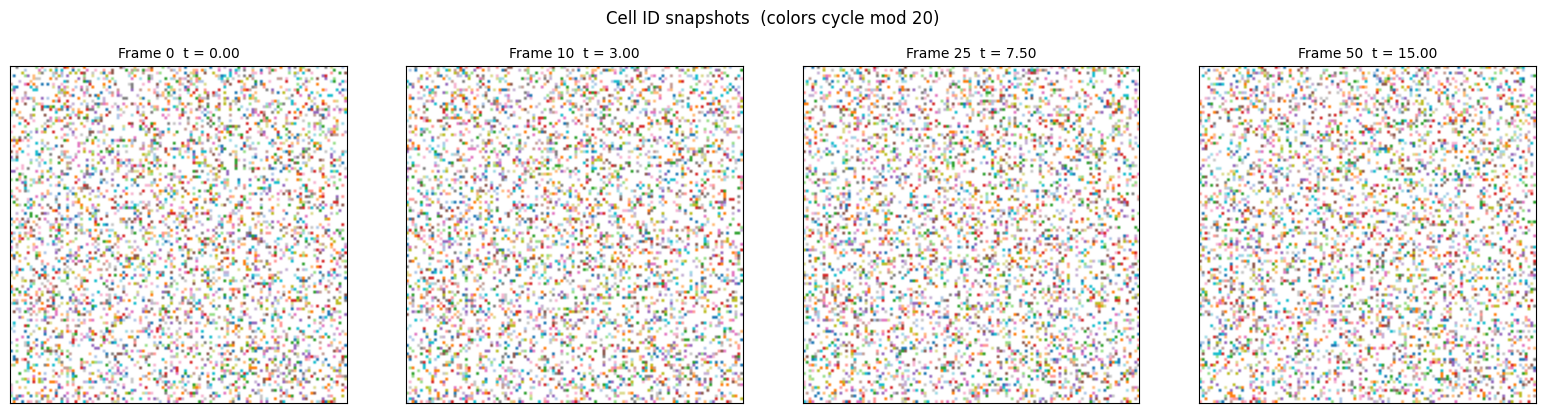

In [5]:
actual_frames = [fi % len(plot_list) for fi in snap_frames]

# 21-color map: index 0 = white (empty), 1-20 = tab20 colors cycling by ID mod 20
id_cmap = mcolors.ListedColormap(['white'] + list(mpl.cm.tab20.colors))

fig, axes = plt.subplots(1, len(actual_frames), figsize=(4 * len(actual_frames), 4))
for ax, fi in zip(np.atleast_1d(axes), actual_frames):
    grid = plot_list[fi]
    display = np.where(grid > 0, (grid % 20) + 1, 0)
    ax.imshow(display, cmap=id_cmap, vmin=0, vmax=20, origin='upper')
    ax.set_title('Frame {}  t = {:.2f}'.format(fi, frame_times[fi]), fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Cell ID snapshots  (colors cycle mod 20)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 2 — Population count over time

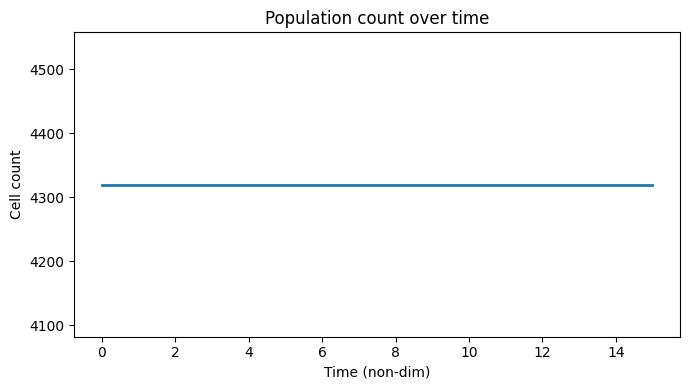

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_out, A_out, linewidth=2)
ax.set_xlabel('Time (non-dim)')
ax.set_ylabel('Cell count')
ax.set_title('Population count over time')
plt.tight_layout()
plt.show()

### 3 — Density surface (space x time)

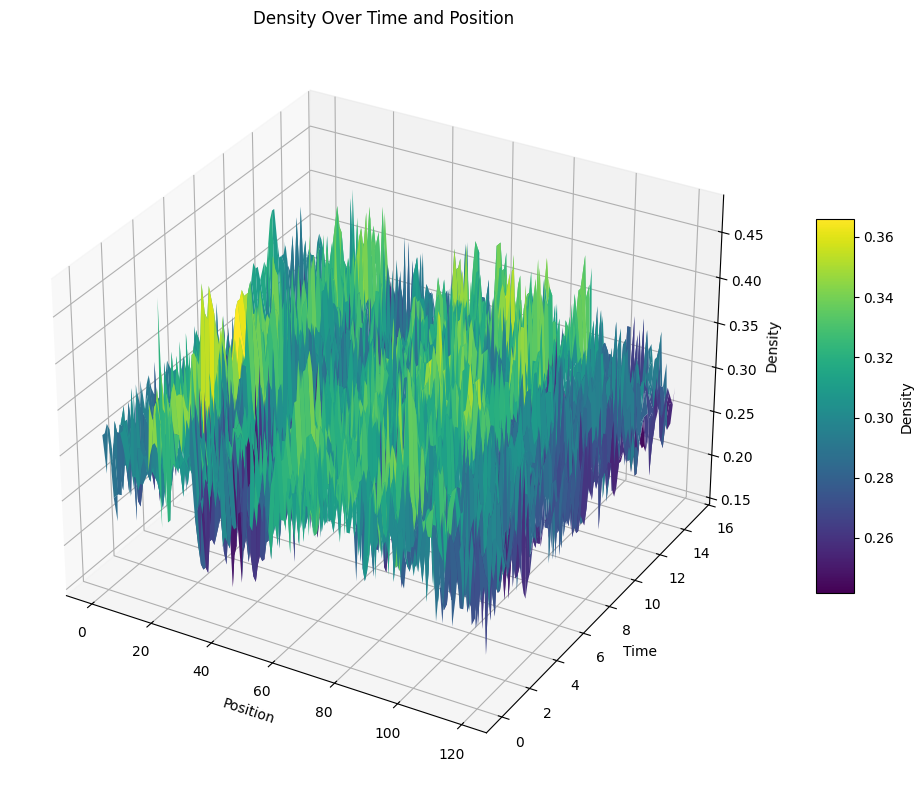

In [7]:
plot_density_3d(t_out, interp_profiles)

### 4 — Cell trajectories

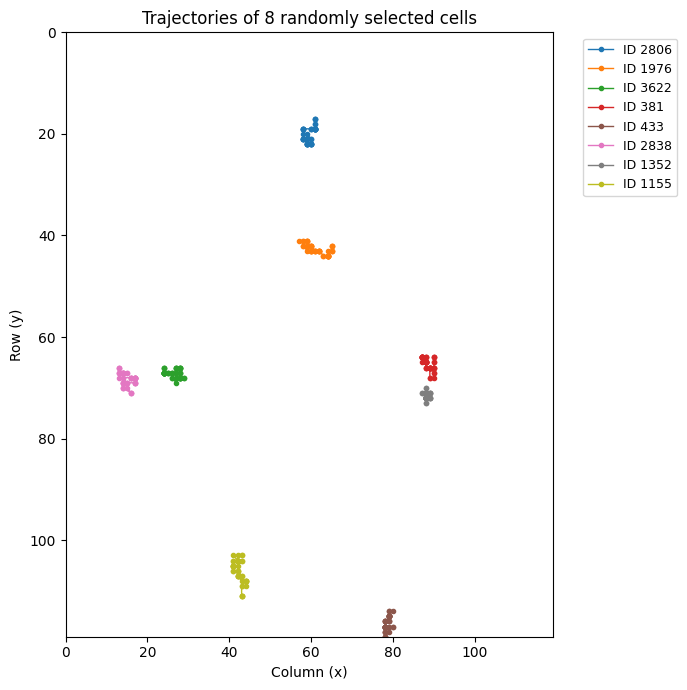

In [8]:
np.random.seed(0)
initial_ids = plot_list[0][plot_list[0] > 0]
track_ids = np.random.choice(initial_ids, min(n_track, len(initial_ids)), replace=False)

fig, ax = plt.subplots(figsize=(7, 7))
colors = [mpl.cm.tab10(i / len(track_ids)) for i in range(len(track_ids))]

for cell_id, color in zip(track_ids, colors):
    xs, ys = [], []
    for frame in plot_list:
        pos = np.argwhere(frame == cell_id)
        if len(pos) > 0:
            xs.append(int(pos[0][1]))   # col -> x
            ys.append(int(pos[0][0]))   # row -> y
        else:
            xs.append(None)             # cell absent this frame
            ys.append(None)
    ax.plot(xs, ys, '-o', color=color, markersize=3, linewidth=1,
            label='ID {}'.format(cell_id))

ax.set_xlim(0, 119)
ax.set_ylim(0, 119)
ax.invert_yaxis()
ax.set_xlabel('Column (x)')
ax.set_ylabel('Row (y)')
ax.set_title('Trajectories of {} randomly selected cells'.format(len(track_ids)))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()